In [1]:
from amms.core.analysis.maps import Map2D
from amms.core.plotting.maps import show_map, panel_grid
from amms.core.analysis.sky import sky_aspect
from amms.core.config.paths import products_root

from pathlib import Path

FIGS = Path.cwd().parent / "figures"
FIGS.mkdir(exist_ok=True)

PRODUCTS = products_root() / "b12_model2"

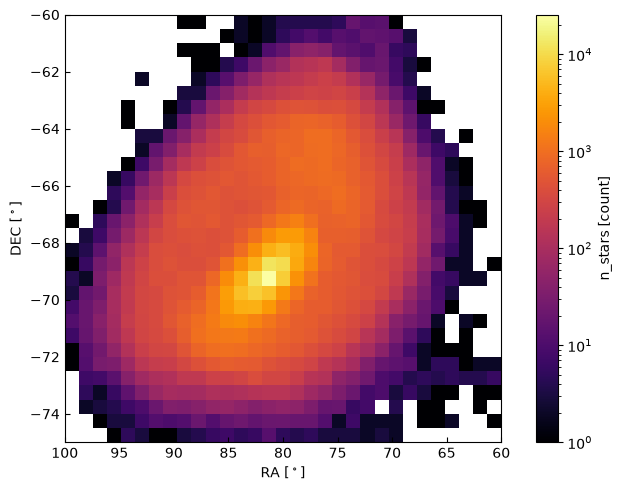

In [2]:
m_all = Map2D.load(PRODUCTS / "lmc_069_radec_allstars.npz")

lon0, lon1, lat0, lat1 = m_all.extent
aspect = sky_aspect((lat0 + lat1) / 2.0)

show_map(m_all, log=True, min_counts=1, aspect=aspect, cmap="inferno")

In [3]:
slice_paths = sorted((PRODUCTS / "sfr_radec_slices").glob("lmc_069_age*myr.npz"))
maps = [Map2D.load(p) for p in slice_paths]
titles = [f"{m.meta['age_min_gyr']*1000:.0f}-{(m.meta['age_min_gyr']+m.meta['dt_gyr'])*1000:.0f} Myr" for m in maps]

print(len(maps), "slices found")

10 slices found


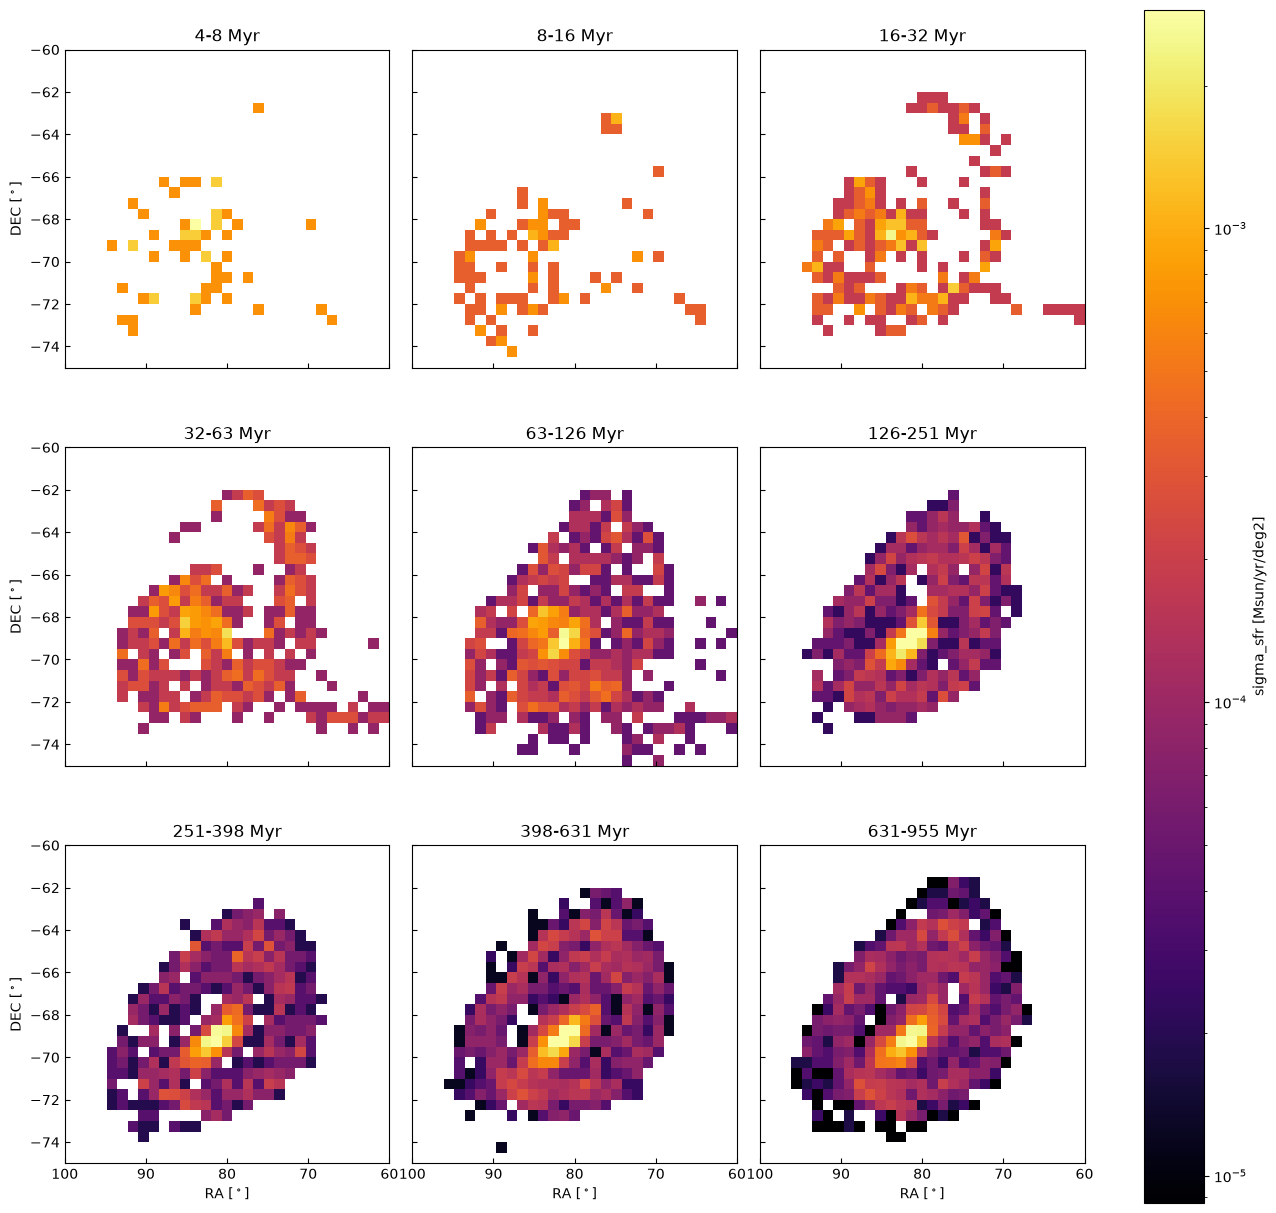

In [12]:
stride = 4  # 96 -> 24 panels, a readable 4x6 grid
overview_maps = maps[::stride]
overview_titles = titles[::stride]

fig, axes = panel_grid(maps[1:], ncols=3, log=True, min_counts=1,
                        percentiles=(1, 99.5), titles=titles[1:],
                        cmap="inferno", aspect=aspect, h_pad=0.001, w_pad=0.001, hspace=0.001, wspace=0.001)
fig.savefig(FIGS / "sfr_slices.png", dpi=300, bbox_inches="tight")

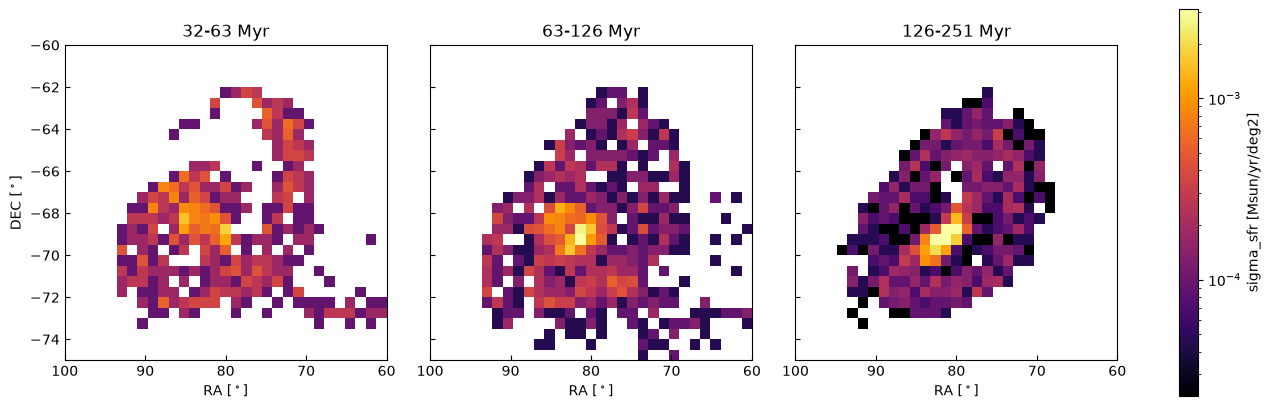

In [13]:
slice_select_i = 4
slice_select_f = 7

fig, axes = panel_grid(maps[slice_select_i:slice_select_f], ncols=3, log=True, min_counts=1,
                        percentiles=(1, 99.5), titles=titles[slice_select_i:slice_select_f],
                        cmap="inferno", aspect=aspect)
fig.savefig(FIGS / f"sfr_slice_{slice_select_i}-{slice_select_f}.png", dpi=300, bbox_inches="tight")